<a href="https://colab.research.google.com/github/NdopnnoabasiJames/Machine-Learning-Models/blob/main/DBSCAN_on_Wholesale_Customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Density-Based Clustering with DBSCAN: Wholesale Customer Segmentation**


In this notebook, I apply DBSCAN (Density-Based Spatial Clustering of Applications with Noise) to a real world wholesale customers dataset.

The goal is to discover natural customer groupings based on purchasing behavior and identify potential outliers without predefining the number of clusters.

This project focuses on understanding how density-based clustering differs from K-Means and Hierarchical Clustering, and when it is more appropriate for real, messy data.


## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# These libraries are used for data manipulation, visualization, feature scaling, and applying the DBSCAN clustering algorithm.

## Loading of dataset and basic exploration

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ML_Datasets/Wholesale customers data.csv")

print(df.shape)

print(df.info)

print(df.isnull().sum())

(440, 8)
<bound method DataFrame.info of      Channel  Region  Fresh   Milk  Grocery  Frozen  Detergents_Paper  \
0          2       3  12669   9656     7561     214              2674   
1          2       3   7057   9810     9568    1762              3293   
2          2       3   6353   8808     7684    2405              3516   
3          1       3  13265   1196     4221    6404               507   
4          2       3  22615   5410     7198    3915              1777   
..       ...     ...    ...    ...      ...     ...               ...   
435        1       3  29703  12051    16027   13135               182   
436        1       3  39228   1431      764    4510                93   
437        2       3  14531  15488    30243     437             14841   
438        1       3  10290   1981     2232    1038               168   
439        1       3   2787   1698     2510      65               477   

     Delicassen  
0          1338  
1          1776  
2          7844  
3         

Basic exploration helps me check what type of data I'm working with, see how the features are distributed, and make sure there aren't any missing values. Since DBSCAN relies heavily on measuring distances between data points, I need to understand the scale and spread of my features before I start cleaning things up.

## Select Features for Clustering


In [ ]:
features = df[
    ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
]

features.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


For clustering, only product-related purchase features were selected.

The Channel and Region columns were excluded because they are categorical identifiers and would distort distance calculations if treated as numerical values.

## Scale the Features


In [ ]:
# DBSCAN uses Euclidean distance, so scaling is mandatory.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

Feature scaling was applied using standardization to ensure that all variables contribute equally to distance calculations.

This step is especially important for DBSCAN, as the algorithm is highly sensitive to differences in feature scale.

## Choose eps Using the k-distance Plot

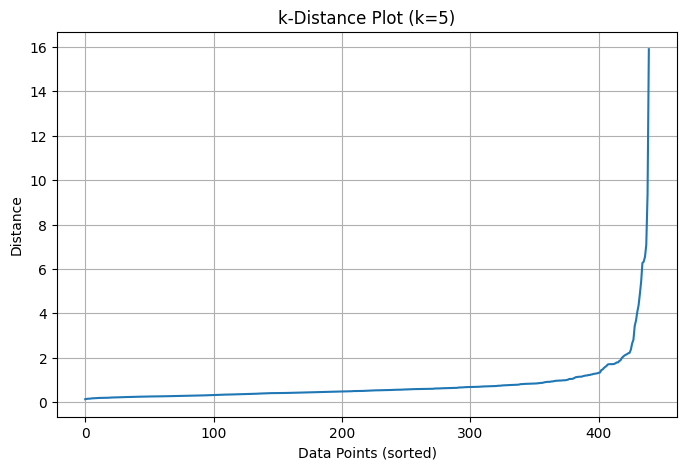

In [ ]:
# Instead of guessing eps, we visualize it
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 4])

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.title("k-Distance Plot (k=5)")
plt.xlabel("Data Points (sorted)")
plt.ylabel("Distance")
plt.grid(True) # Added gridlines
plt.show()

## Apply DBSCAN

In [ ]:
dbscan = DBSCAN(
    eps=1.8,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df['Cluster'] = dbscan_labels

df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,2,3,12669,9656,7561,214,2674,1338,0
1,2,3,7057,9810,9568,1762,3293,1776,0
2,2,3,6353,8808,7684,2405,3516,7844,0
3,1,3,13265,1196,4221,6404,507,1788,0
4,2,3,22615,5410,7198,3915,1777,5185,0


## Inspect Cluster Results

In [ ]:
df['Cluster'].value_counts().sort_index()

,count
Cluster,
-1,16
0,424


The eps parameter was selected based on the elbow observed in the k-distance plot.

DBSCAN was then applied to identify dense customer groups and explicitly label sparse observations as noise, allowing for the detection of outliers alongside meaningful clusters.

## Visualize clusters (using PCA for clarity)

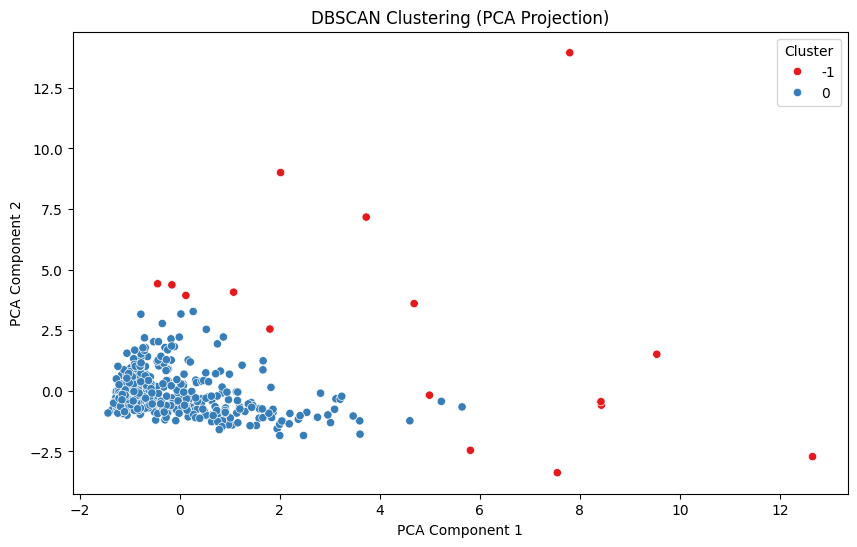

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df['Cluster'],
    palette='Set1',
    legend='full'
)

plt.title("DBSCAN Clustering (PCA Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

DBSCAN was applied to the wholesale customers dataset to identify dense purchasing patterns and detect outliers.

The algorithm identified a single dominant cluster representing the majority of customers with similar buying behavior, while explicitly labeling a small number of customers as noise. These noise points likely correspond to customers with unusual or extreme purchasing patterns.

This demonstrates DBSCAN’s strength in handling real-world data by identifying outliers instead of forcing all observations into predefined clusters, making it particularly useful for anomaly detection and exploratory analysis.